# Agent Supervisor

![](https://d.pr/i/gKezSO+)

In [3]:
%pip install -Uq langchain langchain-openai langchain-community langchain-tavily langchain-experimental langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['TAVILY_API_KEY'] = os.getenv("tavily_key")

## 도구 생성

In [5]:
from langchain_tavily import TavilySearch
from langchain_experimental.tools import PythonREPLTool

tavily_tool = TavilySearch(max_results=3)
python_repl_tool = PythonREPLTool() # 보안위험 있음.


In [6]:
# 헬퍼함수
# - 에이젼트 노드 실행기: 각 에이젼트의 답변을 사람메세지로 재가공.
from langchain_core.messages import HumanMessage

def agent_node(state, agent, name):
    response = agent.invoke(state)
    return {'messages': [HumanMessage(content=response['messages'][-1].content, name=name)]}

## Supervisor Agent

In [7]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.chat_models import init_chat_model
from enum import Enum
from pydantic import BaseModel
from typing import Literal

members = ['Researcher', 'Coder'] # 하위 에이젼트
system_prompt = """
다음 작업자들 간의 대화를 관리하는 관리자로서 당신은 다음 작업을 수행해야 합니다: {members}.

아래의 사용자 요청을 참고하여, 다음 작업을 수행할 작업자를 지정하세요.
각 작업자는 작업을 수행하고 그 결과와 상태를 보고할 것입니다.
모든 작업이 완료되면 FINISH로 응답하세요."
"""

options = members + ['FINISH']

class RouteResponse(BaseModel):
    next: Literal["FINISH", "Researcher", "Coder"]

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    MessagesPlaceholder(variable_name='messages'),
    ('system', '''
위 대화를 참고하여, 누가 다음으로 행동해야 하나요? 아니면 작업을 FINISH 해야 하나요?
다음중 하나를 선택하세요: {options}
''')
]).partial(options=options, members=', '.join(members))

llm = init_chat_model('gpt-4.1')

def supervisor_agent(state):
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)
    return supervisor_chain.invoke(state)




c:\Users\Playdata\llm\llm_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Graph 조립

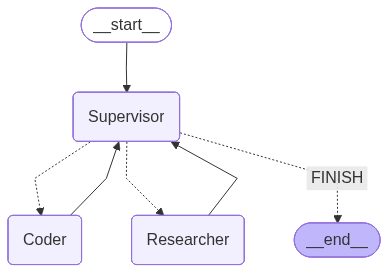

In [8]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from langchain.agents import create_agent
import functools

class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    next: str

# functools.partial(): 기존함수의 일부인자를 미리 채운 함수를 반환
research_agent = create_agent(llm, tools=[tavily_tool])
research_node = functools.partial(agent_node, agent=research_agent, name='Researcher')

code_agent = create_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name='Coder')


# 그래프 작성
workflow = StateGraph(AgentState)
workflow.add_node("Researcher", research_node)
workflow.add_node("Coder", code_node)
workflow.add_node("Supervisor", supervisor_agent)

# 시작 -> Suvervisor
# Supervisor -> Researcher/Coder/END
# Researcher -> Supervisor
# Coder -> Supervisor
workflow.add_edge(START, 'Supervisor')
workflow.add_edge('Researcher', 'Supervisor')
workflow.add_edge('Coder', 'Supervisor')

conditional_map = {
    member: member for member in members
}
conditional_map['FINISH'] = END
workflow.add_conditional_edges('Supervisor', lambda state: state['next'], conditional_map)
graph = workflow.compile()
graph

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content='다음은 2026년 1월 12일부터 2월 12일 기준 삼성전자 주식의 일자별 종가 주요 데이터입니다.\n\n| 날짜           | 종가(원) |\n|:-----------:|:--------:|\n| 2026-02-11  | 166,800  |\n| 2026-02-10  | 166,800  |\n| 2026-02-09  | 166,800  |\n| 2026-02-06  | 158,600  |\n| 2026-02-05  | 159,300  |\n| 2026-02-04  | 169,100  |\n| 2026-02-03  | 167,500  |\n| 2026-02-02  | 150,400  |\n| 2026-01-30  | 160,500  |\n| 2026-01-29  | 160,700  |\n| 2026-01-28  | 162,400  |\n| 2026-01-27  | 159,500  |\n| 2026-01-26  | 152,100  |\n| 2026-01-23  | 152,100  |\n| 2026-01-22  | 152,300  |\n| 2026-01-21  | 149,500  |\n| 2026-01-20  | 145,200  |\n| 2026-01-19  | 149,300  |\n| 2026-01-16  | 148,900  |\n| 2026-01-15  | 143,900  |\n| 2026-01-14  | 140,300  |\n| 2026-01-13  | 137,600  |\n| 2026-01-12  | 138,800  |\n\n이 데이터를 바탕으로 matplotlib 코드 예시를 아래에 제공합니다.\n\n```python\nimport matplotlib.pyplot as plt\nimport matplotlib.dates as mdates\nfrom datetime import datetim

<string>:27: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
<string>:27: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
<string>:27: UserW

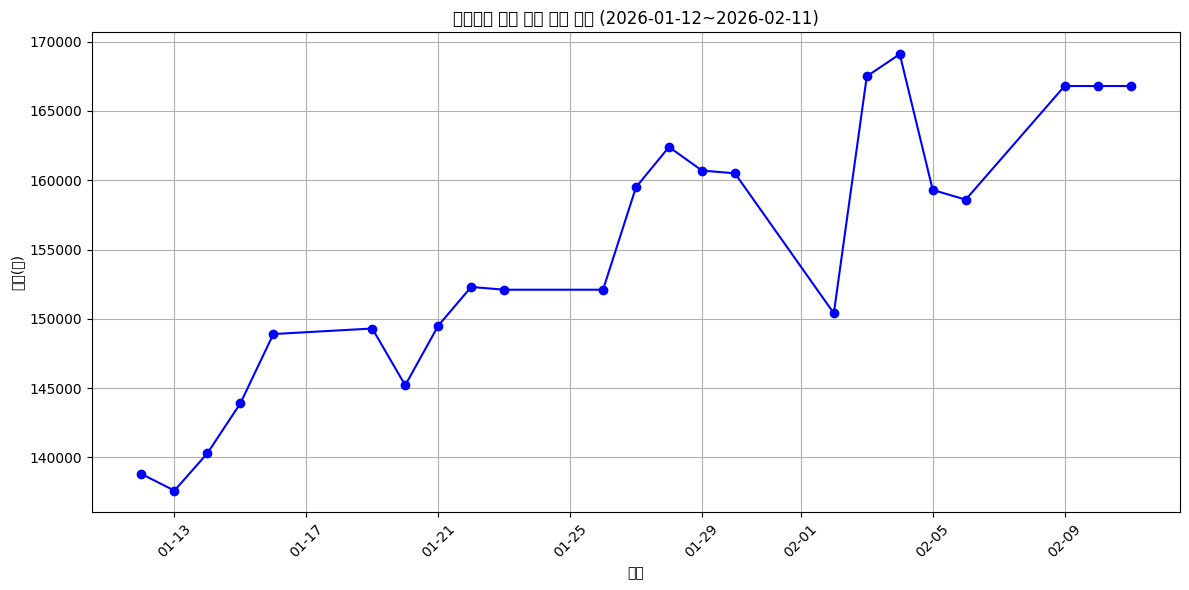

{'Coder': {'messages': [HumanMessage(content='아래의 코드를 실행하면, 2026년 1월 12일부터 2월 11일까지 삼성전자 주식의 최근 한달 종가 추이를 matplotlib로 확인할 수 있습니다.\n\n```python\nimport matplotlib.pyplot as plt\nimport matplotlib.dates as mdates\nfrom datetime import datetime\n\n# 날짜와 종가 데이터\ndates = [\n    "2026-01-12", "2026-01-13", "2026-01-14", "2026-01-15", "2026-01-16", "2026-01-19",\n    "2026-01-20", "2026-01-21", "2026-01-22", "2026-01-23", "2026-01-26", "2026-01-27",\n    "2026-01-28", "2026-01-29", "2026-01-30", "2026-02-02", "2026-02-03", "2026-02-04",\n    "2026-02-05", "2026-02-06", "2026-02-09", "2026-02-10", "2026-02-11"\n]\nprices = [\n    138800, 137600, 140300, 143900, 148900, 149300, 145200, 149500, 152300, 152100,\n    152100, 159500, 162400, 160700, 160500, 150400, 167500, 169100,\n    159300, 158600, 166800, 166800, 166800\n]\ndates = [datetime.strptime(day, "%Y-%m-%d") for day in dates]\n\nplt.figure(figsize=(12, 6))\nplt.plot(dates, prices, marker=\'o\', linestyle=\'-\', color=\'b\')\nplt.title(

In [12]:
# 코드 생성 요청
for chunk in graph.stream({
    'messages': [
        # ('human', '파이썬 Helloworld 출력하는 코드 작성하고, 콘솔에 출력해줘.')
        ('human', '오늘 2026년 2월 12일 기준 삼성전자 주식 최근 한달 추이를 matplotlib 시각화해줘')
    ]
}):
    print(chunk)

<string>:25: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
<string>:25: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
<string>:25: Us

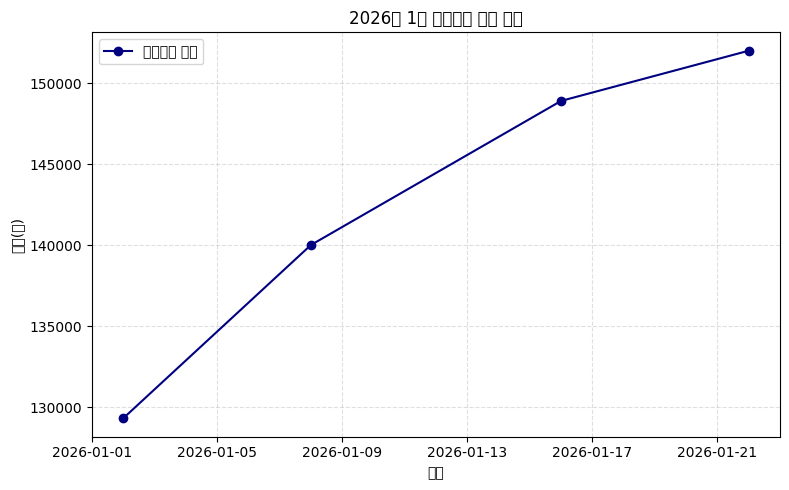

아래 코드는 2026년 1월 기준 삼성전자 주가의 최근 주요 추이를 matplotlib로 시각화하는 예시입니다. 위에서 안내드린 데이터(1월 2일, 1월 8일, 1월 16일, 1월 22일 기준 가격)를 바탕으로 그래프를 그릴 수 있습니다.

```python
import matplotlib.pyplot as plt
import datetime

# 예시 데이터 (2026년 1월 기준)
dates = [
    datetime.date(2026, 1, 2),
    datetime.date(2026, 1, 8),
    datetime.date(2026, 1, 16),
    datetime.date(2026, 1, 22)
]
prices = [
    129300,  # 1월 2일
    140000,  # 1월 8일(임의값)
    148900,  # 1월 16일
    152000   # 1월 22일(추정)
]

plt.figure(figsize=(8,5))
plt.plot(dates, prices, marker='o', color='navy', label='삼성전자 종가')
plt.title('2026년 1월 삼성전자 주가 추이')
plt.xlabel('날짜')
plt.ylabel('주가(원)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
```

위 코드를 그대로 복사해 Python 환경(jupyter notebook, pycharm 등)에서 실행하면 삼성전자 2026년 1월 주가 상승 추이가 일목요연하게 나타나는 시계열 차트를 볼 수 있습니다. 
실제 더 많은 일별 데이터가 필요하다면 데이터만 확장해서 적용하시면 됩니다.

In [10]:
from IPython.display import Markdown

response = graph.invoke({
    'messages': [
        ('human', '오늘 2026년 1월 22일 기준 삼성전자 주식 최근 추이를 matplotlib 시각화해줘')
    ]
})
Markdown(response['messages'][-1].content)

In [11]:
# 자료조사 요청
for chunk in graph.stream({
    'messages': [
        ('human', '저속노화에 대한 레포트 작성해줘')
    ]
}):
    print(chunk)

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content='물론입니다! “저속노화(低速老化, Slow Aging)”에 대한 레포트 예시를 아래에 작성해 드리겠습니다. 필요에 따라 구조나 분량을 조절하실 수 있습니다.\n\n---\n\n# 저속노화에 대한 레포트\n\n## 1. 서론\n\n현대 사회에서 인간의 기대 수명이 점차 증가함에 따라, 단순한 장수보다 건강하게 오래 사는 ‘건강수명’에 대한 관심이 커지고 있다. 이러한 맥락에서 ‘저속노화’는 노화 속도를 늦추고, 노화를 늦춤으로써 질병 없는 삶을 추구하는 새로운 개념으로 주목받고 있다. 본 레포트에서는 저속노화의 정의, 원인, 실천 전략, 최신 연구동향 등에 대해 살펴보고자 한다.\n\n---\n\n## 2. 저속노화의 정의\n\n저속노화란 노화의 진행을 최대한 늦추는 것을 의미한다. 노화는 신체 기능이 점진적으로 저하되는 자연스러운 과정이지만, 식습관, 생활습관, 유전, 환경 등 다양한 요인에 의해 속도가 결정된다. 저속노화는 개인이 노화의 진행을 조절하고자 과학적, 실용적 방법을 도입하는 것을 통칭한다.\n\n---\n\n## 3. 노화의 주요 요인\n\n1. **유전적 요인:** 가족력 및 유전자 구조는 노화 속도에 큰 영향을 준다.\n2. **환경적 요인:** 대기 오염, 자외선, 독성 물질 노출 등은 노화를 촉진한다.\n3. **생활습관:** 식습관, 운동, 수면, 스트레스 관리 등이 노화에 큰 영향을 미친다.\n\n---\n\n## 4. 저속노화를 위한 실천 전략\n\n1. **균형 잡힌 식사 및 영양소 섭취**\n   - 항산화 식품(베리류, 토마토, 브로콜리 등)과 건강한 지방(올리브유, 견과류 등) 중심의 식단\n   - 과도한 당분, 가공식품, 트랜스지방 섭취 지양\n\n2. **규칙적인 운동**\n   - 유산소 운동(걷기, 달리기, 자전거 타기 등)\n   - 근력 운동을 병행하여 신